# ST-VMD GK — 500 ms windows, no overlap (K=8)

**Pipeline overview (per-window then subject-level):**

```
Raw audio (DAICWOZ_split)
        │
        ▼
[Segmentation]  500 ms non-overlapping windows (8 000 samples, hop=8 000)
        │  features already extracted in DAICWOZ_stvmd_500ms_k8
        ▼
[ST-VMD K=8]  per window: energy(8,) | frequency(8,) | stability(8,)
              concatenated → feature matrix (n_windows, 24) per subject
        │
        ▼
[Step 1]  Load raw feature matrices — separate TRAIN/TEST, DEP/HEALTH
        │
        ▼
[Step 2]  Gaussian Kernel (GK) mode selection
          • Build mode-vector R³ = [energy_k, freq_k, stab_k] per window
          • Compute RBF cross-kernel score between DEP and HEALTH clouds (TRAIN only)
          • Low score → well-separated → discriminative mode
          • Select 4 modes with lowest score out of K=8
        │
        ▼
[Step 3]  Global normalization + subject-level aggregation
          • Fit StandardScaler on ALL concatenated TRAIN windows (no per-subject fit)
          • For each subject: transform windows → apply selected 4 modes → (n_windows, 12)
          • Compute 10 temporal statistics on X_sel and Δ(X_sel):
            mean | std | median | skewness | kurtosis
          • Result: 1 vector of 120 features per subject
        │
        ▼
[Step 4]  Subject-level classification — GridSearchCV (balanced_accuracy)
          • 5 models: DecisionTree, RandomForest, GradientBoosting, SVM, XGBoost
          • StratifiedKFold(5) on TRAIN subjects
          • Evaluate on TEST subjects (no window-level leakage)
```

**Key design choices:**
- Classification unit: **subject** (not window) — one prediction per patient
- GK selection uses TRAIN data only — no leakage
- Global scaler fitted on TRAIN windows only — no leakage
- Non-overlapping windows — independent samples within each subject

## Step 1 — Load raw ST-VMD features

Load per-subject `.npy` arrays for `energy`, `frequency`, and `stability` (each `(n_windows, 8)`) and concatenate horizontally to obtain `(n_windows, 24)` per subject.
Subjects are split into four lists: TRAIN/TEST × DEP/HEALTH. No data from TEST subjects is used in Steps 2 or 3 (no leakage).

In [1]:
from pathlib import Path 
import numpy as np
import pandas as pd

features_dir  = Path(r"D:\DAICWOZ_stvmd_500ms_k8")
manifest_path = features_dir / "processed_manifest.csv"
STVMD_K       = 8
features      = ["energy", "frequency", "stability"]
GRUPOS_TARGET = ["FEMALE_DEP", "FEMALE_HEALTH"]

manifest = pd.read_csv(str(manifest_path))
manifest = manifest[manifest['grupo'].isin(GRUPOS_TARGET)].copy()

train_dep_raws,    train_dep_ids    = [], []
train_health_raws, train_health_ids = [], []
test_dep_raws,     test_dep_ids     = [], []
test_health_raws,  test_health_ids  = [], []

for _, row in manifest.iterrows():
    subject_id = str(row['subject_id'])
    split      = row['split']
    grupo      = row['grupo']
    src_dir    = features_dir / f"{split}_{grupo}"
    arrays, missing = [], False
    for feat in features:
        path = src_dir / f"{subject_id}_{feat}_k{STVMD_K}.npy"
        if not path.exists():
            print(f'No encontrado: {path.name}')
            missing = True; break
        arrays.append(np.load(str(path)))
    if missing:
        continue
    X_raw = np.concatenate(arrays, axis=1)   # (n_windows, 24)
    if   split == "TRAIN" and grupo == "FEMALE_DEP":
        train_dep_raws.append(X_raw);    train_dep_ids.append(subject_id)
    elif split == "TRAIN" and grupo == "FEMALE_HEALTH":
        train_health_raws.append(X_raw); train_health_ids.append(subject_id)
    elif split == "TEST"  and grupo == "FEMALE_DEP":
        test_dep_raws.append(X_raw);     test_dep_ids.append(subject_id)
    elif split == "TEST"  and grupo == "FEMALE_HEALTH":
        test_health_raws.append(X_raw);  test_health_ids.append(subject_id)

print(f'TRAIN DEP    : {len(train_dep_raws)} subjects')
print(f'TRAIN HEALTH : {len(train_health_raws)} subjects')
print(f'TEST DEP     : {len(test_dep_raws)} subjects')
print(f'TEST HEALTH  : {len(test_health_raws)} subjects')
if train_dep_raws:
    print(f'Example shape (first DEP TRAIN subject): {train_dep_raws[0].shape}  -> (n_windows_500ms, 24)')

TRAIN DEP    : 24 subjects
TRAIN HEALTH : 43 subjects
TEST DEP     : 7 subjects
TEST HEALTH  : 11 subjects
Example shape (first DEP TRAIN subject): (653, 24)  -> (n_windows_500ms, 24)


## Step 1.5 — Basic descriptive statistics (TRAIN/TEST × DEP/HEALTH)

Before any GK selection or feature extraction, build a per-subject table (one row per subject
with its window count / duration) and a group-level summary (n subjects, total windows,
mean/std/min/median/max windows per subject). Since each window is exactly 1 s with no overlap,
`n_windows` is also the duration in seconds.

In [3]:
groups = {
    ("TRAIN", "FEMALE_DEP"):    (train_dep_raws,    train_dep_ids),
    ("TRAIN", "FEMALE_HEALTH"): (train_health_raws, train_health_ids),
    ("TEST",  "FEMALE_DEP"):    (test_dep_raws,     test_dep_ids),
    ("TEST",  "FEMALE_HEALTH"): (test_health_raws,  test_health_ids),
}

subject_rows = []
for (split, grupo), (X_list, ids_list) in groups.items():
    for X, sid in zip(X_list, ids_list):
        subject_rows.append({
            "subject_id":  sid,
            "split":       split,
            "grupo":       grupo,
            "n_windows":   X.shape[0],
            "duration_s":  round(X.shape[0] * 0.5, 1),  # 1 ventana = 0.5 s, sin overlap
        })

subjects_df = pd.DataFrame(subject_rows)
print("=== Estadistica por sujeto (1 ventana = 0.5 s, sin overlap) ===")
print(subjects_df.to_string(index=False))

summary_df = subjects_df.groupby(["split", "grupo"])["n_windows"].agg(
    n_subjects="count", total_windows="sum", mean_windows="mean",
    std_windows="std", min_windows="min", median_windows="median", max_windows="max"
).round(1).reset_index()

print("\n=== Resumen por grupo ===")
print(summary_df.to_string(index=False))

print("\n=== Balance de clases ===")
for split in ["TRAIN", "TEST"]:
    n_dep    = summary_df.loc[(summary_df.split == split) & (summary_df.grupo.str.endswith("DEP")),    "n_subjects"].iloc[0]
    n_health = summary_df.loc[(summary_df.split == split) & (summary_df.grupo.str.endswith("HEALTH")), "n_subjects"].iloc[0]
    print(f"  {split}: {int(n_dep)} dep / {int(n_health)} health  "
          f"(ratio dep:health = 1:{n_health/n_dep:.2f})")

=== Estadistica por sujeto (1 ventana = 0.5 s, sin overlap) ===
subject_id split         grupo  n_windows  duration_s
       308 TRAIN    FEMALE_DEP        653       326.5
       311 TRAIN    FEMALE_DEP        401       200.5
       320 TRAIN    FEMALE_DEP        498       249.0
       321 TRAIN    FEMALE_DEP        580       290.0
       325 TRAIN    FEMALE_DEP       1029       514.5
       332 TRAIN    FEMALE_DEP        597       298.5
       335 TRAIN    FEMALE_DEP        862       431.0
       337 TRAIN    FEMALE_DEP       2565      1282.5
       346 TRAIN    FEMALE_DEP       1306       653.0
       348 TRAIN    FEMALE_DEP        592       296.0
       350 TRAIN    FEMALE_DEP        917       458.5
       351 TRAIN    FEMALE_DEP        813       406.5
       352 TRAIN    FEMALE_DEP        999       499.5
       362 TRAIN    FEMALE_DEP        534       267.0
       376 TRAIN    FEMALE_DEP       1060       530.0
       377 TRAIN    FEMALE_DEP       1607       803.5
       386 TRAIN  

## Step 1.6 — Volume ratio TRAIN_FEMALE_HEALTH vs TRAIN_FEMALE_DEP (informational only)

Same calculation as Step 1.6 in the MALE notebook, but **no windows are modified here** — just
checking the percentage relationship between groups for FEMALE.

In [ ]:
dep_total    = sum(X.shape[0] for X in train_dep_raws)
health_total = sum(X.shape[0] for X in train_health_raws)
ratio        = health_total / dep_total
target_total = 2 * dep_total
keep_fraction_if_applied = target_total / health_total

print(f'TRAIN_FEMALE_DEP    total windows : {dep_total}')
print(f'TRAIN_FEMALE_HEALTH total windows : {health_total}')
print(f'Ratio HEALTH/DEP                  : {ratio:.2f}x  ({ratio*100:.1f}%)')
print(f'\n--- Solo informativo, NO se modifica nada ---')
print(f'Objetivo equivalente al de MALE (2x dep) : {target_total}')
if keep_fraction_if_applied < 1.0:
    print(f'keep_fraction que se necesitaria         : {keep_fraction_if_applied:.4f} '
          f'({keep_fraction_if_applied*100:.1f}%) -> habria que reducir HEALTH')
else:
    print(f'keep_fraction que se necesitaria         : {keep_fraction_if_applied:.4f} '
          f'({keep_fraction_if_applied*100:.1f}%) -> HEALTH ya esta por debajo de 2x dep, no haria falta reducir')

# --- TEST: misma informacion, sin modificar nada ---
test_dep_total    = sum(X.shape[0] for X in test_dep_raws)
test_health_total = sum(X.shape[0] for X in test_health_raws)
test_ratio        = test_health_total / test_dep_total
test_target_total = 2 * test_dep_total
test_keep_fraction_if_applied = test_target_total / test_health_total

print(f'\n--- TEST (informativo, sin modificar) ---')
print(f'TEST_FEMALE_DEP    total windows : {test_dep_total}')
print(f'TEST_FEMALE_HEALTH total windows : {test_health_total}')
print(f'Ratio HEALTH/DEP                  : {test_ratio:.2f}x  ({test_ratio*100:.1f}%)')
if test_keep_fraction_if_applied < 1.0:
    print(f'keep_fraction que se necesitaria  : {test_keep_fraction_if_applied:.4f} '
          f'({test_keep_fraction_if_applied*100:.1f}%) -> habria que reducir HEALTH si se aplicase la misma regla')
else:
    print(f'keep_fraction que se necesitaria  : {test_keep_fraction_if_applied:.4f} '
          f'({test_keep_fraction_if_applied*100:.1f}%) -> HEALTH ya esta por debajo de 2x dep, no haria falta reducir')

TRAIN_FEMALE_DEP    total windows : 24242
TRAIN_FEMALE_HEALTH total windows : 44579
Ratio HEALTH/DEP                  : 1.84x  (183.9%)

--- Solo informativo, NO se modifica nada ---
Objetivo equivalente al de MALE (2x dep) : 48484
keep_fraction que se necesitaria         : 1.0876 (108.8%) -> HEALTH ya esta por debajo de 2x dep, no haria falta reducir

--- TEST (informativo, sin modificar) ---
TEST_FEMALE_DEP    total windows : 6910
TEST_FEMALE_HEALTH total windows : 10416
Ratio HEALTH/DEP                  : 1.51x  (150.7%)
keep_fraction que se necesitaria  : 1.3268 (132.7%) -> HEALTH ya esta por debajo de 2x dep, no haria falta reducir


## Step 2 — Gaussian Kernel (GK) mode selection

For each of the K=8 VMD modes, we build a **mode-vector** in R³ = `[energy_k, freq_k, stab_k]` for every window, then concatenate all TRAIN windows per class.

Class separability is measured via the **RBF cross-kernel**:

$$K[i,j] = \exp\!\left(-\frac{\|A_i - B_j\|^2}{2\sigma^2}\right)$$

where σ² is estimated with the **median heuristic** on a random subsample (no TEST data used).

- **High score** → overlapping distributions → non-discriminative mode
- **Low score** → separated distributions → discriminative mode

The **4 modes with the lowest score** are selected for feature extraction.

In [5]:
N_SELECT = 4

def mode_vector(X_list, k):
    return np.concatenate(
        [np.stack([X[:, k], X[:, k + STVMD_K], X[:, k + 2 * STVMD_K]], axis=1)
         for X in X_list], axis=0).astype(np.float64)

def rbf_cross_score(A, B, chunk_size=200):
    rng    = np.random.default_rng(42)
    n_samp = min(2000, len(A), len(B))
    Asamp  = A[rng.choice(len(A), n_samp, replace=False)]
    Bsamp  = B[rng.choice(len(B), n_samp, replace=False)]
    diff2  = ((Asamp[:, None, :] - Bsamp[None, :, :]) ** 2).sum(axis=2)
    sigma2 = float(np.median(diff2)) + 1e-12
    # Chunked kernel to avoid OOM with large window counts
    k_sum = 0.0
    for i in range(0, len(A), chunk_size):
        A_chunk = A[i:i + chunk_size]
        d2 = ((A_chunk[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)
        k_sum += np.exp(-d2 / (2 * sigma2)).sum()
    return k_sum / (len(A) * len(B)), sigma2

scores = []
for k in range(STVMD_K):
    dep_k         = mode_vector(train_dep_raws,    k)
    health_k      = mode_vector(train_health_raws, k)
    score, sigma2 = rbf_cross_score(dep_k, health_k)
    scores.append(score)
    print(f'  Mode {k}: score={score:.4f}  sigma2={sigma2:.2f}'
          f'  (dep={len(dep_k)} win, health={len(health_k)} win)')

scores          = np.array(scores)
ranking         = np.argsort(scores)
selected_modes  = sorted(ranking[:N_SELECT].tolist())
discarded_modes = sorted(ranking[N_SELECT:].tolist())

print(f'\nSelected modes  (lowest score, most discriminative): {selected_modes}')
print(f'Discarded modes (highest score, most overlapping)   : {discarded_modes}')
print(f'\nScores per mode: {np.round(scores, 4).tolist()}')

  Mode 0: score=0.5201  sigma2=8905121.18  (dep=24242 win, health=44579 win)
  Mode 1: score=0.5103  sigma2=5299675.56  (dep=24242 win, health=44579 win)
  Mode 2: score=0.5289  sigma2=1375374.64  (dep=24242 win, health=44579 win)
  Mode 3: score=0.5594  sigma2=1048435.59  (dep=24242 win, health=44579 win)
  Mode 4: score=0.5643  sigma2=1442585.06  (dep=24242 win, health=44579 win)
  Mode 5: score=0.5566  sigma2=1727226.76  (dep=24242 win, health=44579 win)
  Mode 6: score=0.5482  sigma2=1542766.58  (dep=24242 win, health=44579 win)
  Mode 7: score=0.5228  sigma2=988997.36  (dep=24242 win, health=44579 win)

Selected modes  (lowest score, most discriminative): [0, 1, 2, 7]
Discarded modes (highest score, most overlapping)   : [3, 4, 5, 6]

Scores per mode: [0.5201, 0.5103, 0.5289, 0.5594, 0.5643, 0.5566, 0.5482, 0.5228]


## Step 3 — Global normalization and subject-level feature extraction

**Normalization strategy:** `StandardScaler` is fitted on **all TRAIN windows concatenated** (not per-subject). This avoids inflating intra-subject variance estimates and ensures a single consistent scale across all subjects.

**Feature extraction per subject:**
1. Transform windows with the global scaler → `(n_windows, 24)`
2. Select columns for the 4 GK-chosen modes → `(n_windows, 12)` (3 features × 4 modes)
3. Compute the discrete temporal derivative Δ: `delta[t] = X[t] - X[t-1]`
4. Compute statistics over the temporal axis (axis=0):

| Statistic     | On X_sel (12) | On delta (12) | Rationale |
|---------------|:---:|:---:|---|
| Skewness      | ✓   | ✓   | Tail asymmetry |
| Kurtosis      | ✓   | ✓   | Tail weight vs centre |
| Std           | ✓   | ✓   | Overall dispersion |
| Mean          | ✓   | ✓   | Central tendency |
| Median        | ✓   | ✓   | Robust central tendency |
| IQR (p75−p25) | ✓   | ✓   | Robust dispersion |
| Mode          | ✓   | ✓   | Most frequent value |

**Output:** one vector of **168 features** per subject `[7 stats × 2 (X_sel + Δ) × 12 cols]`.

In [6]:
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler
import joblib

output_dir = Path(r"D:\DAICWOZ_stvmd_500ms_k8_gk_global")
output_dir.mkdir(parents=True, exist_ok=True)

labels_map = {"FEMALE_DEP": 1, "FEMALE_HEALTH": 0}

def compute_delta(arr):
    delta     = np.zeros_like(arr)
    delta[1:] = arr[1:] - arr[:-1]
    return delta

def subject_features_gk(X_norm, sel_modes):
    """
    Aggregate all windows of one subject into a single feature vector.
    X_norm    : (n_windows, 24) — globally normalized
    sel_modes : list of 4 selected mode indices
    Returns   : (168,)  [7 stats x 2 (X_sel + delta) x 12 cols]

    X_sel stats : skewness | kurtosis | std | mean | median | IQR(p75-p25) | mode
    delta stats : skewness | kurtosis | std | mean | median | IQR(p75-p25) | mode
    """
    cols  = [c for k in sel_modes for c in (k, k + STVMD_K, k + 2 * STVMD_K)]
    X_sel = X_norm[:, cols]          # (n_windows, 12)
    delta = compute_delta(X_sel)
    return np.concatenate([
        sp_stats.skew(X_sel, axis=0),
        sp_stats.kurtosis(X_sel, axis=0),
        X_sel.std(axis=0),
        X_sel.mean(axis=0),
        np.median(X_sel, axis=0),
        np.percentile(X_sel, 75, axis=0) - np.percentile(X_sel, 25, axis=0),
        sp_stats.mode(X_sel, axis=0, keepdims=False)[0],
        sp_stats.skew(delta, axis=0),
        sp_stats.kurtosis(delta, axis=0),
        delta.std(axis=0),
        delta.mean(axis=0),
        np.median(delta, axis=0),
        np.percentile(delta, 75, axis=0) - np.percentile(delta, 25, axis=0),
        sp_stats.mode(delta, axis=0, keepdims=False)[0],
    ])  # (168,)

# Fit global scaler on ALL concatenated TRAIN windows
X_all_train   = np.vstack(train_dep_raws + train_health_raws)
scaler_global = StandardScaler()
scaler_global.fit(X_all_train)
print(f'Global scaler fitted on {X_all_train.shape[0]} TRAIN windows')

def extract_group(X_raws, ids, grupo):
    X_list, y_list, id_list = [], [], []
    for X_raw, sid in zip(X_raws, ids):
        X_norm = scaler_global.transform(X_raw)
        X_list.append(subject_features_gk(X_norm, selected_modes))
        y_list.append(labels_map[grupo])
        id_list.append(sid)
        print(f'  {grupo:15s} | {sid:>4s}: {X_raw.shape[0]:>4} windows -> (168,)')
    return X_list, y_list, id_list

print('\n[TRAIN]')
Xtrd, ytrd, idtrd = extract_group(train_dep_raws,    train_dep_ids,    "FEMALE_DEP")
Xtrh, ytrh, idtrh = extract_group(train_health_raws, train_health_ids, "FEMALE_HEALTH")
print('\n[TEST]')
Xted, yted, idted = extract_group(test_dep_raws,     test_dep_ids,     "FEMALE_DEP")
Xteh, yteh, idteh = extract_group(test_health_raws,  test_health_ids,  "FEMALE_HEALTH")

X_train   = np.vstack(Xtrd + Xtrh);  y_train   = np.array(ytrd + ytrh)
ids_train = np.array(idtrd + idtrh)
X_test    = np.vstack(Xted + Xteh);  y_test    = np.array(yted + yteh)
ids_test  = np.array(idted + idteh)

np.save(str(output_dir / "X_train.npy"),        X_train)
np.save(str(output_dir / "y_train.npy"),        y_train)
np.save(str(output_dir / "ids_train.npy"),      ids_train)
np.save(str(output_dir / "X_test.npy"),         X_test)
np.save(str(output_dir / "y_test.npy"),         y_test)
np.save(str(output_dir / "ids_test.npy"),       ids_test)
np.save(str(output_dir / "selected_modes.npy"), np.array(selected_modes))
joblib.dump(scaler_global, str(output_dir / "scaler_global.pkl"))

print(f'\nNormalization : Global StandardScaler (fitted on TRAIN, {X_all_train.shape[0]} windows)')
print(f'Features/subject : 168  [7 stats x 2 (X_sel + delta) x 12 cols (4 modes x 3 features)]')
print(f'Selected modes   : {selected_modes}')
print(f'X_train : {X_train.shape}  — {(y_train==1).sum()} dep, {(y_train==0).sum()} health')
print(f'X_test  : {X_test.shape}   — {(y_test==1).sum()} dep, {(y_test==0).sum()} health')
print(f'\nSaved to: {output_dir}')

Global scaler fitted on 68821 TRAIN windows

[TRAIN]
  FEMALE_DEP      |  308:  653 windows -> (168,)
  FEMALE_DEP      |  311:  401 windows -> (168,)
  FEMALE_DEP      |  320:  498 windows -> (168,)
  FEMALE_DEP      |  321:  580 windows -> (168,)
  FEMALE_DEP      |  325: 1029 windows -> (168,)
  FEMALE_DEP      |  332:  597 windows -> (168,)
  FEMALE_DEP      |  335:  862 windows -> (168,)
  FEMALE_DEP      |  337: 2565 windows -> (168,)
  FEMALE_DEP      |  346: 1306 windows -> (168,)
  FEMALE_DEP      |  348:  592 windows -> (168,)
  FEMALE_DEP      |  350:  917 windows -> (168,)
  FEMALE_DEP      |  351:  813 windows -> (168,)
  FEMALE_DEP      |  352:  999 windows -> (168,)
  FEMALE_DEP      |  362:  534 windows -> (168,)
  FEMALE_DEP      |  376: 1060 windows -> (168,)
  FEMALE_DEP      |  377: 1607 windows -> (168,)
  FEMALE_DEP      |  386: 1301 windows -> (168,)
  FEMALE_DEP      |  402:  895 windows -> (168,)
  FEMALE_DEP      |  405: 1707 windows -> (168,)
  FEMALE_DEP    

## Step 4 — Subject-level classification with GridSearchCV

Eight classifiers are tuned with `GridSearchCV` using **balanced accuracy** as the scoring metric to compensate for the class imbalance (24 dep vs 43 health in TRAIN).

**Cross-validation:** `StratifiedKFold(5)` where each sample is a **subject** — no window-level leakage is possible since windows from the same subject are never split.

**Class imbalance handling:**
- DecisionTree, RandomForest, SVM, LogisticRegression: `class_weight='balanced'`
- GradientBoosting: `sample_weight` balanced (via `compute_sample_weight`)
- XGBoost: `scale_pos_weight = n_health / n_dep`
- KNN, NaiveBayes (GaussianNB): no native class weighting in scikit-learn — left unweighted (KNN's `weights='distance'` option is tuned as a partial mitigation)

**Confidence intervals:** 95% CI via **percentile bootstrap** (n=2000 resamplings of the 18 test subjects). Metrics reported: Precision, Recall, Specificity, F1, ROC-AUC.

**Plots:** ROC curve and Precision-Recall curve for all models on the test set.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE   = 42
n_dep_train    = int((y_train == 1).sum())
n_health_train = int((y_train == 0).sum())
N_SPLITS       = min(5, n_dep_train, n_health_train)
cv             = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'X_train : {X_train.shape}  -- {n_dep_train} dep, {n_health_train} health')
print(f'X_test  : {X_test.shape}   -- {(y_test==1).sum()} dep, {(y_test==0).sum()} health')
print(f'CV: StratifiedKFold(n_splits={N_SPLITS}) — each sample is a subject, no leakage')

fit_params_per_model = {
    'GradientBoosting': {'sample_weight': compute_sample_weight('balanced', y_train)}
}

def compute_metrics(model, X_t, y_t):
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()
    return {
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy':     accuracy_score(y_t, y_pred),
        'bal_accuracy': balanced_accuracy_score(y_t, y_pred),
        'precision':    precision_score(y_t, y_pred, zero_division=0),
        'recall':       recall_score(y_t, y_pred, zero_division=0),
        'specificity':  tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'f1':           f1_score(y_t, y_pred, zero_division=0),
        'roc_auc':      roc_auc_score(y_t, y_proba),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def bootstrap_ci(y_true, y_pred, y_proba, n_boot=10000, alpha=0.05, seed=0):
    """95% CI via percentile bootstrap on the test set subjects."""
    rng  = np.random.default_rng(seed)
    n    = len(y_true)
    boot = {k: [] for k in ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc']}
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_proba[idx]
        if len(np.unique(yt)) < 2:
            continue
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(yt, yp).ravel()
        boot['accuracy'].append(accuracy_score(yt, yp))
        boot['precision'].append(precision_score(yt, yp, zero_division=0))
        boot['recall'].append(recall_score(yt, yp, zero_division=0))
        boot['specificity'].append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0)
        boot['f1'].append(f1_score(yt, yp, zero_division=0))
        boot['roc_auc'].append(roc_auc_score(yt, ypr))
    return {k: (np.percentile(v, 100*alpha/2), np.percentile(v, 100*(1-alpha/2)))
            for k, v in boot.items()}

models_grids = {
    'DecisionTree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        {'criterion': ['gini', 'entropy'],
         'max_depth': [3, 5, 10, 15, None],
         'min_samples_split': [2, 5, 10, 20],
         'min_samples_leaf': [1, 2, 4]},
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
        {'n_estimators': [100, 200, 500],
         'max_depth': [5, 10, 20, None],
         'max_features': ['sqrt', 'log2'],
         'min_samples_split': [2, 5, 10],
         'min_samples_leaf': [1, 2, 4]},
    ),
    'GradientBoosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200, 300],
         'learning_rate': [0.05, 0.1, 0.2],
         'max_depth': [2, 3, 5],
         'subsample': [0.7, 0.85, 1.0],
         'min_samples_leaf': [1, 2, 4]},
    ),
    'SVM': (
        SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'),
        {'C': [0.01, 0.1, 1, 10, 100],
         'kernel': ['rbf', 'linear'],
         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]},
    ),
    'XGBoost': (
        xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1,
                          scale_pos_weight=n_health_train / n_dep_train),
        {'n_estimators': [100, 200, 300],
         'learning_rate': [0.05, 0.1, 0.2],
         'max_depth': [2, 3, 5],
         'subsample': [0.7, 0.85, 1.0],
         'colsample_bytree': [0.7, 1.0],
         'min_child_weight': [1, 3, 5],
         'reg_alpha': [0, 0.1, 1.0]},
    ),
    'LogisticRegression': (
        LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=2000),
        {'C': [0.001, 0.01, 0.1, 1, 10, 100],
         'penalty': ['l1', 'l2'],
         'solver': ['liblinear']},
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9, 11, 15],
         'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan']},
    ),
    'NaiveBayes': (
        GaussianNB(),
        {'var_smoothing': np.logspace(0, -9, 10)},
    ),
}

results = {}
for model_name, (estimator, param_grid) in models_grids.items():
    print(f"\n{'='*60}\n  {model_name}\n{'='*60}")
    gs = GridSearchCV(estimator, param_grid, cv=cv, scoring='balanced_accuracy',
                      n_jobs=-1, verbose=0, refit=True)
    fit_kw = fit_params_per_model.get(model_name, {})
    gs.fit(X_train, y_train, **fit_kw)
    m  = compute_metrics(gs.best_estimator_, X_test, y_test)
    ci = bootstrap_ci(y_test, m['y_pred'], m['y_proba'])
    detail = pd.DataFrame({
        'subject': ids_test, 'true': y_test, 'pred': m['y_pred'],
        'proba': m['y_proba'].round(3), 'correct': y_test == m['y_pred'],
    })
    results[model_name] = {
        'best_params': gs.best_params_, 'cv_score': gs.best_score_,
        'y_true': y_test, 'y_proba': m['y_proba'], 'ci': ci,
        **{k: v for k, v in m.items() if k not in ('y_pred','y_proba','tn','fp','fn','tp')},
    }
    def fmt(k): return f"{m[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f'\n  Best parameters : {gs.best_params_}')
    print(f'\n  Confusion matrix:')
    print(f'                 Pred Health  Pred Dep')
    print(f"  True Health        {m['tn']:>3}         {m['fp']:>3}")
    print(f"  True Dep           {m['fn']:>3}         {m['tp']:>3}")
    print(f'\n  Test metrics  (value [95% CI bootstrap]):')
    print(f"    Accuracy     : {fmt('accuracy')}")
    print(f"    Precision    : {fmt('precision')}")
    print(f"    Recall/Sens. : {fmt('recall')}")
    print(f"    Specificity  : {fmt('specificity')}")
    print(f"    F1           : {fmt('f1')}")
    print(f"    ROC AUC      : {fmt('roc_auc')}")
    print(f'\n  Per-subject detail:')
    print(detail.to_string(index=False))

print('\n\n=== FINAL SUMMARY  (sorted by ROC AUC — value [95% CI bootstrap]) ===')
hdr = (f"{'Model':<20} {'ROC':>22} {'Accuracy':>22} {'Recall':>22} "
       f"{'Prec':>22} {'Spec':>22} {'F1':>22}")
print(hdr)
print('-' * len(hdr))
for name, res in sorted(results.items(), key=lambda x: x[1]['roc_auc'], reverse=True):
    ci = res['ci']
    def f(k): return f"{res[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f"{name:<20} {f('roc_auc'):>22} {f('accuracy'):>22} {f('recall'):>22} "
          f"{f('precision'):>22} {f('specificity'):>22} {f('f1'):>22}")

X_train : (67, 168)  -- 24 dep, 43 health
X_test  : (18, 168)   -- 7 dep, 11 health
CV: StratifiedKFold(n_splits=5) — each sample is a subject, no leakage

  DecisionTree

  Best parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

  Confusion matrix:
                 Pred Health  Pred Dep
  True Health          9           2
  True Dep             5           2

  Test metrics  (value [95% CI bootstrap]):
    Accuracy     : 0.611 [0.389–0.833]
    Precision    : 0.500 [0.000–1.000]
    Recall/Sens. : 0.286 [0.000–0.667]
    Specificity  : 0.818 [0.556–1.000]
    F1           : 0.364 [0.000–0.667]
    ROC AUC      : 0.552 [0.346–0.767]

  Per-subject detail:
subject  true  pred  proba  correct
    338     1     0    0.0    False
    345     1     1    1.0     True
    353     1     0    0.0    False
    372     1     1    1.0     True
    410     1     0    0.0    False
    421     1     0    0.0    False
    440     1     0    0.0    Fa

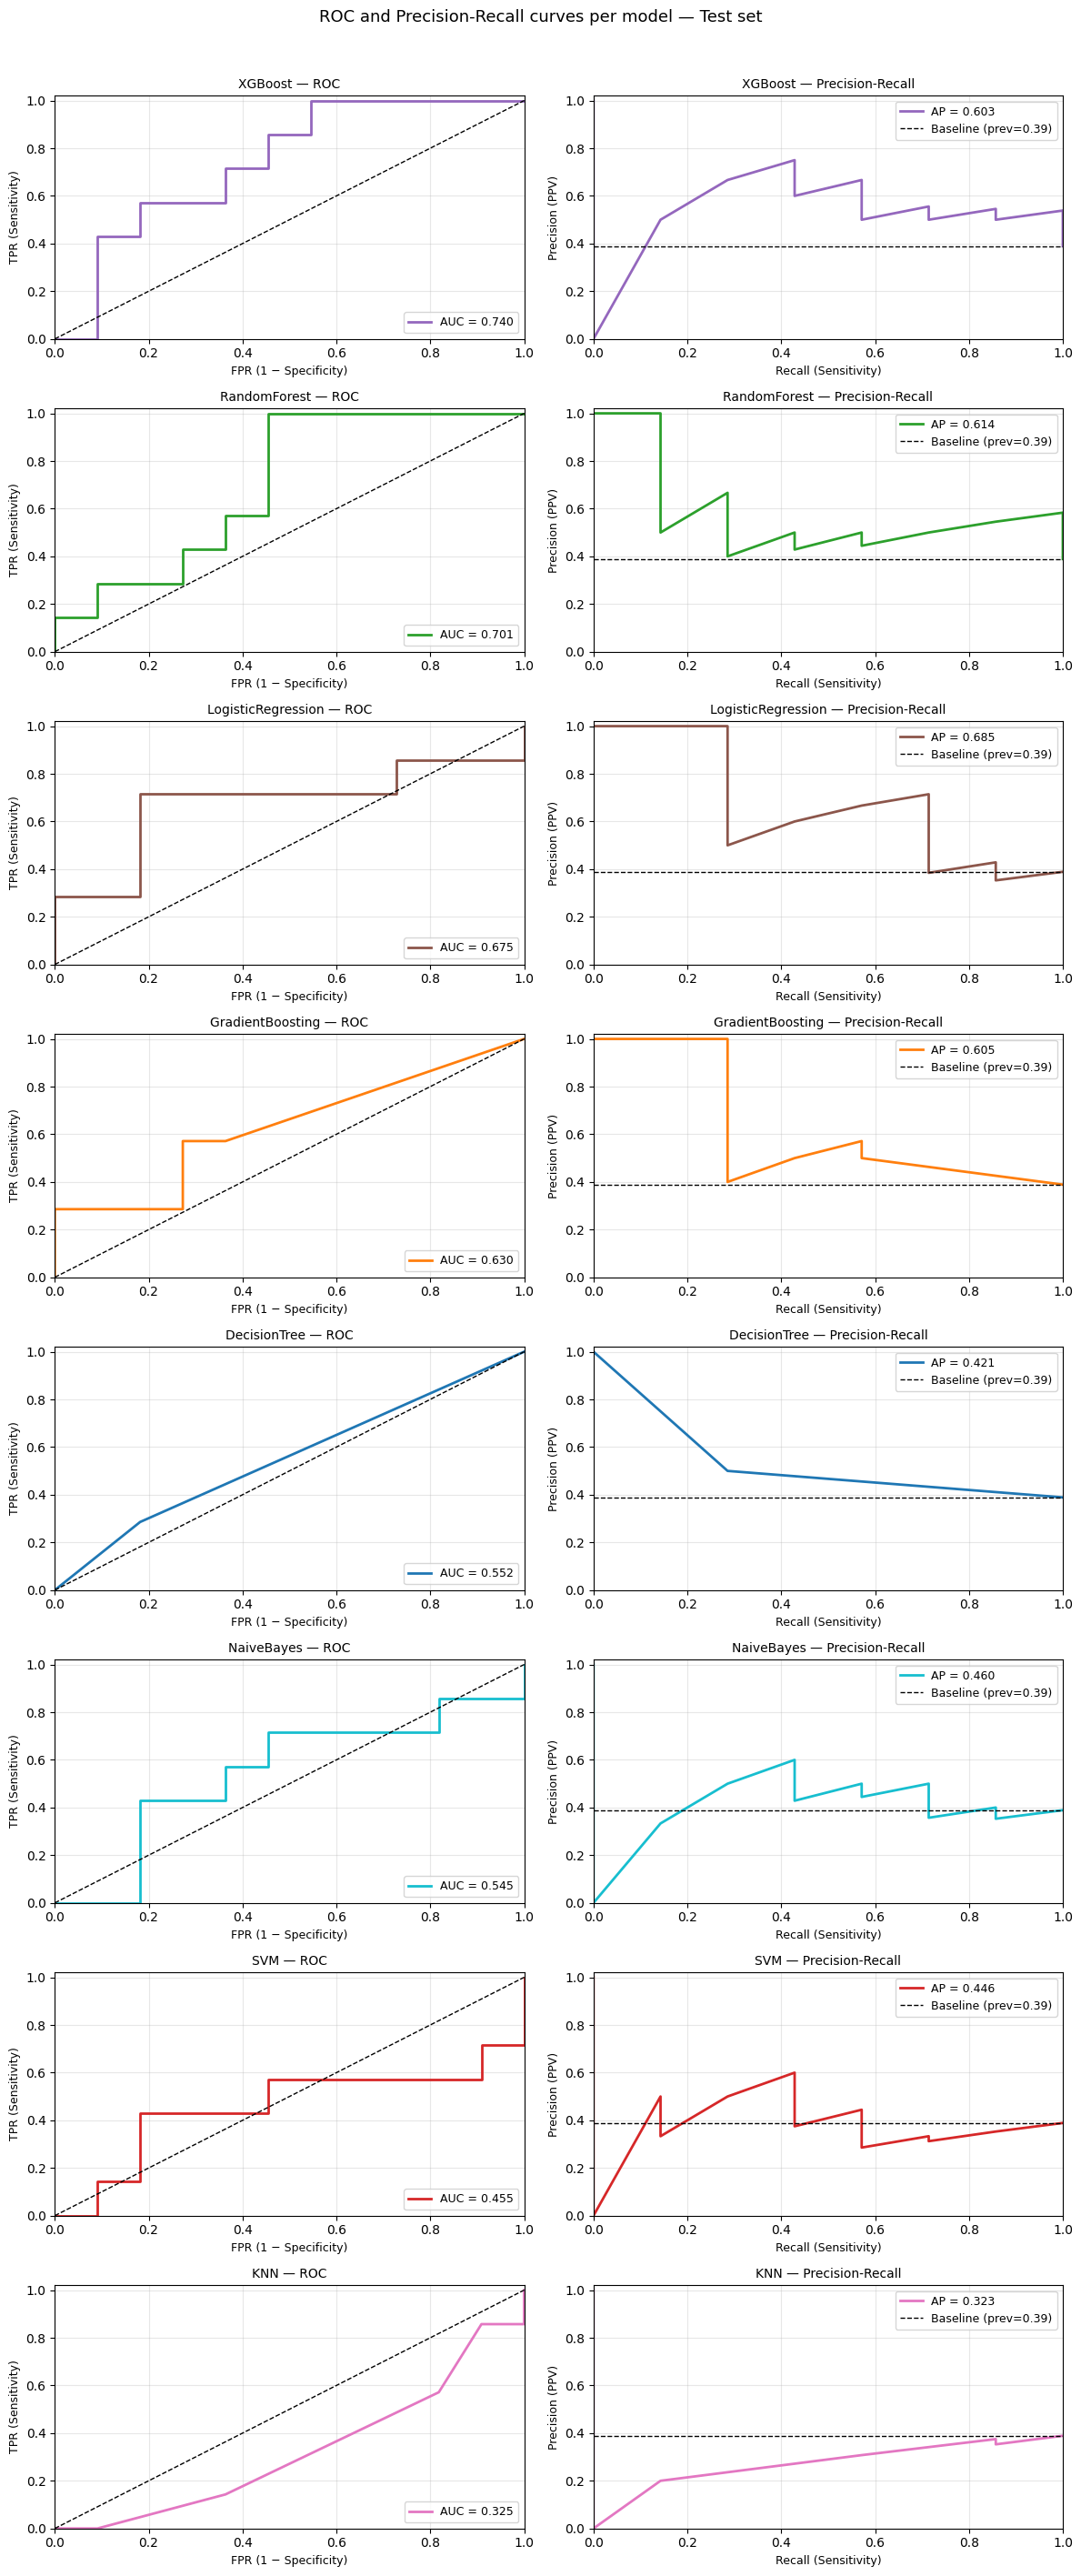

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

COLORS = {
    'DecisionTree':       '#1f77b4',
    'RandomForest':       '#2ca02c',
    'GradientBoosting':   '#ff7f0e',
    'SVM':                '#d62728',
    'XGBoost':            '#9467bd',
    'LogisticRegression': '#8c564b',
    'KNN':                '#e377c2',
    'NaiveBayes':         '#17becf',
}

model_order = sorted(results.keys(), key=lambda x: results[x]['roc_auc'], reverse=True)
n_models    = len(model_order)
prevalence  = y_test.mean()

fig, axes = plt.subplots(n_models, 2, figsize=(12, 3.5 * n_models))
fig.suptitle('ROC and Precision-Recall curves per model — Test set', fontsize=13, y=1.01)

for i, name in enumerate(model_order):
    res   = results[name]
    color = COLORS[name]
    y_true, y_proba = res['y_true'], res['y_proba']

    # --- ROC ---
    ax = axes[i, 0]
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'AUC = {res["roc_auc"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('FPR (1 − Specificity)', fontsize=9)
    ax.set_ylabel('TPR (Sensitivity)', fontsize=9)
    ax.set_title(f'{name} — ROC', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

    # --- Precision-Recall ---
    ax = axes[i, 1]
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    ax.plot(rec, prec, color=color, lw=2,
            label=f'AP = {ap:.3f}')
    ax.axhline(prevalence, color='k', linestyle='--', lw=1,
               label=f'Baseline (prev={prevalence:.2f})')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('Recall (Sensitivity)', fontsize=9)
    ax.set_ylabel('Precision (PPV)', fontsize=9)
    ax.set_title(f'{name} — Precision-Recall', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import GaussianNB

def make_estimator(name):
    """Build a fresh estimator for `name` reusing its best_params from Step 4 GridSearchCV."""
    bp = results[name]['best_params']
    if name == 'DecisionTree':
        return DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', **bp)
    if name == 'RandomForest':
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced', **bp)
    if name == 'GradientBoosting':
        return GradientBoostingClassifier(random_state=RANDOM_STATE, **bp)
    if name == 'XGBoost':
        return xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1,
                                  scale_pos_weight=n_health_train / n_dep_train, **bp)
    if name == 'NaiveBayes':
        return GaussianNB(**bp)
    if name == 'LogisticRegression':
        return LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=2000, **bp)
    raise ValueError(f'Unknown model name: {name}')

# All stacking combinations tried for FEMALE: (base estimators) -> meta-model
stacking_combinations = [
    (['DecisionTree', 'XGBoost'],         'LogisticRegression'),
    (['DecisionTree', 'GradientBoosting'],'LogisticRegression'),
    (['DecisionTree', 'RandomForest'],    'LogisticRegression'),
    (['DecisionTree', 'RandomForest'],    'XGBoost'),
    (['DecisionTree', 'XGBoost'],         'RandomForest'),
    (['DecisionTree', 'RandomForest'],    'GradientBoosting'),
    (['GradientBoosting', 'XGBoost'],     'LogisticRegression'),
    (['GradientBoosting', 'XGBoost'],     'RandomForest'),
    (['GradientBoosting', 'XGBoost'],     'DecisionTree'),
    (['NaiveBayes', 'DecisionTree'],      'LogisticRegression'),
    (['NaiveBayes', 'RandomForest'],      'LogisticRegression'),
    (['NaiveBayes', 'GradientBoosting'],  'LogisticRegression'),
    (['NaiveBayes', 'XGBoost'],           'LogisticRegression'),
]

METRIC_COLS = ['roc_auc', 'accuracy', 'recall', 'precision', 'specificity', 'f1']

print(f"{'='*60}\n  Stacking ensemble comparison\n{'='*60}")
stacking_summary = {}
for base_names, meta_name in stacking_combinations:
    estimators = [(n, make_estimator(n)) for n in base_names]
    final_est  = make_estimator(meta_name)
    stack = StackingClassifier(estimators=estimators, final_estimator=final_est,
                                cv=cv, stack_method='predict_proba', n_jobs=-1)
    stack.fit(X_train, y_train)

    m  = compute_metrics(stack, X_test, y_test)
    ci = bootstrap_ci(y_test, m['y_pred'], m['y_proba'])
    label = f"{'+'.join(base_names)}->{meta_name}"

    entry = {
        'best_params': {n: results[n]['best_params'] for n in base_names + [meta_name]},
        'cv_score': np.nan,
        'y_true': y_test, 'y_proba': m['y_proba'], 'ci': ci,
        **{k: v for k, v in m.items() if k not in ('y_pred', 'y_proba', 'tn', 'fp', 'fn', 'tp')},
    }
    results[f'Stacking({label})'] = entry
    stacking_summary[label] = entry

    def fmt(k): return f"{m[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f"\n  {label}")
    print(f"    ROC AUC      : {fmt('roc_auc')}")
    print(f"    Accuracy     : {fmt('accuracy')}")
    print(f"    Recall/Sens. : {fmt('recall')}")
    print(f"    Precision    : {fmt('precision')}")
    print(f"    Specificity  : {fmt('specificity')}")
    print(f"    F1           : {fmt('f1')}")

print('\n\n=== STACKING COMBINATIONS RANKED BY ROC-AUC (value [95% CI bootstrap]) ===')
hdr = (f"{'Combo':<35} {'ROC':>22} {'Accuracy':>22} {'Recall':>22} "
       f"{'Prec':>22} {'Spec':>22} {'F1':>22}")
print(hdr)
print('-' * len(hdr))
for label, entry in sorted(stacking_summary.items(), key=lambda x: x[1]['roc_auc'], reverse=True):
    ci = entry['ci']
    def f(k): return f"{entry[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f"{label:<35} {f('roc_auc'):>22} {f('accuracy'):>22} {f('recall'):>22} "
          f"{f('precision'):>22} {f('specificity'):>22} {f('f1'):>22}")

  Stacking ensemble comparison

  DecisionTree+XGBoost->LogisticRegression
    ROC AUC      : 0.500 [0.500–0.500]
    Accuracy     : 0.611 [0.389–0.833]
    Recall/Sens. : 0.000 [0.000–0.000]
    Precision    : 0.000 [0.000–0.000]
    Specificity  : 1.000 [1.000–1.000]
    F1           : 0.000 [0.000–0.000]

  DecisionTree+GradientBoosting->LogisticRegression
    ROC AUC      : 0.500 [0.500–0.500]
    Accuracy     : 0.611 [0.389–0.833]
    Recall/Sens. : 0.000 [0.000–0.000]
    Precision    : 0.000 [0.000–0.000]
    Specificity  : 1.000 [1.000–1.000]
    F1           : 0.000 [0.000–0.000]

  DecisionTree+RandomForest->LogisticRegression
    ROC AUC      : 0.500 [0.500–0.500]
    Accuracy     : 0.611 [0.389–0.833]
    Recall/Sens. : 0.000 [0.000–0.000]
    Precision    : 0.000 [0.000–0.000]
    Specificity  : 1.000 [1.000–1.000]
    F1           : 0.000 [0.000–0.000]

  DecisionTree+RandomForest->XGBoost
    ROC AUC      : 0.266 [0.027–0.583]
    Accuracy     : 0.333 [0.111–0.556]
    R

In [10]:
from sklearn.naive_bayes import GaussianNB
from itertools import combinations

def make_estimator(name):
    """Build a fresh estimator for `name` reusing its best_params from Step 4 GridSearchCV."""
    bp = results[name]['best_params']
    if name == 'DecisionTree':
        return DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', **bp)
    if name == 'RandomForest':
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced', **bp)
    if name == 'GradientBoosting':
        return GradientBoostingClassifier(random_state=RANDOM_STATE, **bp)
    if name == 'XGBoost':
        return xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1,
                                  scale_pos_weight=n_health_train / n_dep_train, **bp)
    if name == 'NaiveBayes':
        return GaussianNB(**bp)
    if name == 'LogisticRegression':
        return LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=2000, **bp)
    raise ValueError(f'Unknown model name: {name}')

# All combinations of 3 base estimators drawn from this pool, tried against each meta-model
BASE_POOL     = ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'NaiveBayes', 'LogisticRegression']
META_NAMES    = ['GradientBoosting', 'XGBoost']
triple_combos = list(combinations(BASE_POOL, 3))

print(f"{'='*60}\n  Stacking ensemble comparison — 3 base models -> {META_NAMES}\n{'='*60}")
print(f'  {len(triple_combos)} base combinations x {len(META_NAMES)} meta-models '
      f'= {len(triple_combos) * len(META_NAMES)} total\n')

triple_summary = {}
for meta_name in META_NAMES:
    for base_names in triple_combos:
        base_names = list(base_names)
        estimators = [(n, make_estimator(n)) for n in base_names]
        final_est  = make_estimator(meta_name)
        stack = StackingClassifier(estimators=estimators, final_estimator=final_est,
                                    cv=cv, stack_method='predict_proba', n_jobs=-1)
        stack.fit(X_train, y_train)

        m  = compute_metrics(stack, X_test, y_test)
        ci = bootstrap_ci(y_test, m['y_pred'], m['y_proba'])
        label = f"{'+'.join(base_names)}->{meta_name}"

        entry = {
            'best_params': {n: results[n]['best_params'] for n in set(base_names + [meta_name])},
            'cv_score': np.nan,
            'y_true': y_test, 'y_proba': m['y_proba'], 'ci': ci,
            **{k: v for k, v in m.items() if k not in ('y_pred', 'y_proba', 'tn', 'fp', 'fn', 'tp')},
        }
        results[f'Stacking3({label})'] = entry
        triple_summary[label] = entry

print('=== 3-MODEL STACKING COMBINATIONS RANKED BY ROC-AUC (value [95% CI bootstrap]) ===')
hdr = (f"{'Combo':<55} {'ROC':>22} {'Accuracy':>22} {'Recall':>22} "
       f"{'Prec':>22} {'Spec':>22} {'F1':>22}")
print(hdr)
print('-' * len(hdr))
for label, entry in sorted(triple_summary.items(), key=lambda x: x[1]['roc_auc'], reverse=True):
    ci = entry['ci']
    def f(k): return f"{entry[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f"{label:<55} {f('roc_auc'):>22} {f('accuracy'):>22} {f('recall'):>22} "
          f"{f('precision'):>22} {f('specificity'):>22} {f('f1'):>22}")

  Stacking ensemble comparison — 3 base models -> ['GradientBoosting', 'XGBoost']
  20 base combinations x 2 meta-models = 40 total

=== 3-MODEL STACKING COMBINATIONS RANKED BY ROC-AUC (value [95% CI bootstrap]) ===
Combo                                                                      ROC               Accuracy                 Recall                   Prec                   Spec                     F1
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
GradientBoosting+NaiveBayes+LogisticRegression->GradientBoosting    0.766 [0.475–1.000]    0.611 [0.389–0.833]    0.143 [0.000–0.500]    0.500 [0.000–1.000]    0.909 [0.700–1.000]    0.222 [0.000–0.571]
RandomForest+NaiveBayes+LogisticRegression->GradientBoosting    0.753 [0.472–0.969]    0.722 [0.500–0.944]    0.429 [0.000–0.833]    0.750 [0.000–1.000]    0.909 [0.700–1.000]    0.545 [0.000–0

## Step 6 — Youden's J threshold calibration

Steps 4-5 use the default 0.5 probability threshold. Here we **calibrate the decision
threshold** using **Youden's J statistic** (`J = TPR − FPR`, maximized), computed on
**out-of-fold TRAIN probabilities** (via `cross_val_predict`, same `cv` as Steps 4-5 — no
leakage) for the best-ranked model in each of three tracks:
- Best **single model** (Step 4, highest ROC-AUC)
- Best **2-base-model stacking** (Step 5)
- Best **3-base-model stacking** (Step 5)

The threshold found on TRAIN (out-of-fold) is then applied to the already-computed TEST
probabilities to recompute Accuracy / Precision / Recall / Specificity / F1 — ROC-AUC is
threshold-independent and stays the same. The three recalibrated tracks are ranked by F1 to
identify the most effective model overall after calibration.

Note: with very few TRAIN subjects, pooled out-of-fold probabilities can occasionally produce a
degenerate threshold (J≈0); this is reported as-is rather than silently corrected.

In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


def make_estimator_full(name):
    """Like make_estimator, but also covers SVM and KNN (not used as stacking base/meta)."""
    bp = results[name]['best_params']
    if name == 'SVM':
        return SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced', **bp)
    if name == 'KNN':
        return KNeighborsClassifier(**bp)
    return make_estimator(name)


def youden_threshold(y_true, y_proba):
    """Threshold maximizing Youden's J = TPR - FPR."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])


def recompute_with_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    ci = bootstrap_ci(y_true, y_pred, y_proba)
    return {
        'threshold': threshold, 'ci': ci,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


def print_calibrated(label, y_true, y_proba, threshold, j_stat):
    m  = recompute_with_threshold(y_true, y_proba, threshold)
    ci = m['ci']
    def fmt(k): return f"{m[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    print(f"\n  Youden threshold : {threshold:.4f}  (J={j_stat:.4f})")
    print(f'\n  Confusion matrix:')
    print(f'                 Pred Health  Pred Dep')
    print(f"  True Health        {m['tn']:>3}         {m['fp']:>3}")
    print(f"  True Dep           {m['fn']:>3}         {m['tp']:>3}")
    print(f'\n  Test metrics  (value [95% CI bootstrap]):')
    print(f"    Accuracy     : {fmt('accuracy')}")
    print(f"    Precision    : {fmt('precision')}")
    print(f"    Recall/Sens. : {fmt('recall')}")
    print(f"    Specificity  : {fmt('specificity')}")
    print(f"    F1           : {fmt('f1')}")
    print(f"    ROC AUC      : {fmt('roc_auc')}  (unchanged by threshold)")
    return m


print(f"{'='*60}\n  Step 6 — Youden's J threshold calibration\n{'='*60}")

# ------------------------------------------------------------------
# (a) Best single model from Step 4
# ------------------------------------------------------------------
single_model_names = list(models_grids.keys())
best_single_name   = max(single_model_names, key=lambda n: results[n]['roc_auc'])
print(f"\nBest single model (Step 4, by ROC-AUC): {best_single_name}")

best_single_est  = make_estimator_full(best_single_name)
oof_proba_single = cross_val_predict(best_single_est, X_train, y_train, cv=cv,
                                      method='predict_proba')[:, 1]
thr_single, j_single = youden_threshold(y_train, oof_proba_single)
calib_single = print_calibrated(f'Single model: {best_single_name}',
                                 y_test, results[best_single_name]['y_proba'],
                                 thr_single, j_single)

# ------------------------------------------------------------------
# (b) Best 2-base-model stacking combination
# ------------------------------------------------------------------
best_2_label = max(stacking_summary.keys(), key=lambda l: stacking_summary[l]['roc_auc'])
print(f"\nBest 2-model stacking (by ROC-AUC): {best_2_label}")

base2_names, meta2_name = next(
    (b, m) for b, m in stacking_combinations if f"{'+'.join(b)}->{m}" == best_2_label
)
stack2 = StackingClassifier(
    estimators=[(n, make_estimator_full(n)) for n in base2_names],
    final_estimator=make_estimator_full(meta2_name),
    cv=cv, stack_method='predict_proba', n_jobs=-1,
)
oof_proba_2 = cross_val_predict(stack2, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
thr_2, j_2 = youden_threshold(y_train, oof_proba_2)
calib_2 = print_calibrated(f'2-model stacking: {best_2_label}',
                            y_test, stacking_summary[best_2_label]['y_proba'], thr_2, j_2)

# ------------------------------------------------------------------
# (c) Best 3-base-model stacking combination
# ------------------------------------------------------------------
best_3_label = max(triple_summary.keys(), key=lambda l: triple_summary[l]['roc_auc'])
print(f"\nBest 3-model stacking (by ROC-AUC): {best_3_label}")

base3_part, meta3_name = best_3_label.split('->')
base3_names = base3_part.split('+')
stack3 = StackingClassifier(
    estimators=[(n, make_estimator_full(n)) for n in base3_names],
    final_estimator=make_estimator_full(meta3_name),
    cv=cv, stack_method='predict_proba', n_jobs=-1,
)
oof_proba_3 = cross_val_predict(stack3, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
thr_3, j_3 = youden_threshold(y_train, oof_proba_3)
calib_3 = print_calibrated(f'3-model stacking: {best_3_label}',
                            y_test, triple_summary[best_3_label]['y_proba'], thr_3, j_3)

# ------------------------------------------------------------------
# Summary across the three calibrated tracks
# ------------------------------------------------------------------
calibrated_tracks = {
    f'Single: {best_single_name}': calib_single,
    f'Stacking2: {best_2_label}': calib_2,
    f'Stacking3: {best_3_label}': calib_3,
}
print('\n\n=== BEST MODEL PER TRACK AFTER YOUDEN CALIBRATION  (value [95% CI bootstrap]) ===')
hdr = (f"{'Track':<45} {'ROC':>22} {'Accuracy':>22} {'Recall':>22} "
       f"{'Prec':>22} {'Spec':>22} {'F1':>22}")
print(hdr)
print('-' * len(hdr))
for label, m in sorted(calibrated_tracks.items(), key=lambda x: x[1]['f1'], reverse=True):
    ci = m['ci']
    def f(k): return f"{m[k]:.3f} [{ci[k][0]:.3f}–{ci[k][1]:.3f}]"
    print(f"{label:<45} {f('roc_auc'):>22} {f('accuracy'):>22} {f('recall'):>22} "
          f"{f('precision'):>22} {f('specificity'):>22} {f('f1'):>22}")

overall_best_label = max(calibrated_tracks, key=lambda l: calibrated_tracks[l]['f1'])
print(f"\nMost effective model overall after threshold calibration: {overall_best_label}")

  Step 6 — Youden's J threshold calibration

Best single model (Step 4, by ROC-AUC): XGBoost

  Single model: XGBoost

  Youden threshold : 0.5010  (J=0.3789)

  Confusion matrix:
                 Pred Health  Pred Dep
  True Health         10           1
  True Dep             4           3

  Test metrics  (value [95% CI bootstrap]):
    Accuracy     : 0.722 [0.500–0.889]
    Precision    : 0.750 [0.000–1.000]
    Recall/Sens. : 0.429 [0.000–0.833]
    Specificity  : 0.909 [0.700–1.000]
    F1           : 0.545 [0.000–0.857]
    ROC AUC      : 0.740 [0.475–0.950]  (unchanged by threshold)

Best 2-model stacking (by ROC-AUC): DecisionTree+XGBoost->RandomForest

  2-model stacking: DecisionTree+XGBoost->RandomForest

  Youden threshold : 0.4314  (J=0.3130)

  Confusion matrix:
                 Pred Health  Pred Dep
  True Health          6           5
  True Dep             3           4

  Test metrics  (value [95% CI bootstrap]):
    Accuracy     : 0.556 [0.333–0.778]
    Precision  

In [12]:
# Winner's curse / model selection bias check — ST-VMD GK pipeline (FEMALE)
# Includes all 61 candidates: 8 single + 13 two-stack + 40 three-stack.
# Subject features reuse X_train / X_test from Step 3 (no recomputation needed).
#
# WARNING: 61 candidates x N_REPS repetitions is computationally heavy.
#   Each stacking fit runs its own internal CV. Expect 30-90 min for N_REPS=10.
#   Reduce N_REPS to 5 if computation time is a concern.

import math
import time
import warnings
from itertools import combinations as _combinations
from sklearn.base import clone
from sklearn.ensemble import StackingClassifier

warnings.filterwarnings('ignore')

N_REPS = 10

# ── Build stacking model from label string (reuses make_estimator_full from Step 6) ──
def _build_stacking(combo_str):
    base_part, meta_name = combo_str.split('->')
    base_names = base_part.split('+')
    return StackingClassifier(
        estimators=[(n, make_estimator_full(n)) for n in base_names],
        final_estimator=make_estimator_full(meta_name),
        cv=cv, stack_method='predict_proba', n_jobs=-1,
    )

def build_fixed_model():
    label = overall_best_label
    if label.startswith('Single: '):
        return make_estimator_full(label[len('Single: '):])
    if label.startswith('Stacking2: '):
        return _build_stacking(label[len('Stacking2: '):])
    if label.startswith('Stacking3: '):
        return _build_stacking(label[len('Stacking3: '):])
    raise ValueError(f'Cannot parse overall_best_label: {label!r}')


# ── Build the full candidate pool (61 models) ─────────────────────────────────
_WC_BASE_POOL  = ['DecisionTree', 'RandomForest', 'GradientBoosting',
                  'XGBoost', 'NaiveBayes', 'LogisticRegression']
_WC_META_NAMES = ['GradientBoosting', 'XGBoost']

def build_all_candidates():
    cands = {}
    for name in models_grids:                               # 8 single models
        cands[f'S:{name}'] = make_estimator_full(name)
    for base_names, meta_name in stacking_combinations:     # 13 two-model stacks
        lbl = f"{'+'.join(base_names)}->{meta_name}"
        cands[f'2:{lbl}'] = _build_stacking(lbl)
    for meta_name in _WC_META_NAMES:                        # 40 three-model stacks
        for triple in _combinations(_WC_BASE_POOL, 3):
            lbl = f"{'+'.join(triple)}->{meta_name}"
            cands[f'3:{lbl}'] = _build_stacking(lbl)
    return cands


print(f"Fixed model (Youden winner): {overall_best_label}")
print(f"Candidate pool: {len(build_all_candidates())} models  (N_REPS={N_REPS})")
print()

# ── Collect all subject feature vectors ───────────────────────────────────────
# X_train / X_test are already computed by Step 3. Merge for split permutations.
print("Building all-subject feature matrices from Step 3 outputs...")
t0 = time.time()

all_dep_X  = np.vstack([X_train[y_train == 1], X_test[y_test == 1]])
all_hlth_X = np.vstack([X_train[y_train == 0], X_test[y_test == 0]])

N_DEP        = all_dep_X.shape[0]
N_HLTH       = all_hlth_X.shape[0]
N_DEP_TEST   = int((y_test == 1).sum())
N_HLTH_TEST  = int((y_test == 0).sum())
N_DEP_TRAIN  = int((y_train == 1).sum())
N_HLTH_TRAIN = int((y_train == 0).sum())

print(f"  Done in {time.time()-t0:.1f}s. Subjects: {N_DEP} DEP, {N_HLTH} HEALTH")
print(f"  Test sizes preserved: {N_DEP_TEST} DEP, {N_HLTH_TEST} HEALTH")
print()


def _fit_auc(estimator, X_tr, y_tr, X_te, y_te, seed=None):
    """Clone, optionally set seed, fit, return ROC-AUC (features already normalised)."""
    est = clone(estimator)
    if seed is not None and hasattr(est, 'random_state'):
        est.set_params(random_state=seed)
    est.fit(X_tr, y_tr)
    if len(np.unique(y_te)) < 2:
        return np.nan
    return roc_auc_score(y_te, est.predict_proba(X_te)[:, 1])


def _make_split(dep_perm, hlth_perm):
    """Build train/test matrices from subject-index permutations."""
    X_tr = np.vstack([all_dep_X[dep_perm[N_DEP_TEST:]],
                      all_hlth_X[hlth_perm[N_HLTH_TEST:]]])
    y_tr = np.concatenate([np.ones(N_DEP - N_DEP_TEST),
                           np.zeros(N_HLTH - N_HLTH_TEST)])
    X_te = np.vstack([all_dep_X[dep_perm[:N_DEP_TEST]],
                      all_hlth_X[hlth_perm[:N_HLTH_TEST]]])
    y_te = np.concatenate([np.ones(N_DEP_TEST), np.zeros(N_HLTH_TEST)])
    return X_tr, y_tr, X_te, y_te


# ── Exp 1: Adaptive, FIXED split, varied seeds ────────────────────────────────
print("Exp 1 — Adaptive (all 61 candidates), fixed split, varied seeds:")
exp1_aucs = []
for seed in range(N_REPS):
    t1 = time.time()
    best = 0.0
    for est in build_all_candidates().values():
        auc = _fit_auc(est, X_train, y_train, X_test, y_test, seed=seed)
        if not np.isnan(auc):
            best = max(best, auc)
    exp1_aucs.append(best)
    print(f"  seed={seed}  best_auc={best:.3f}  ({time.time()-t1:.0f}s)")

# ── Exp 2: Adaptive, VARIED splits ───────────────────────────────────────────
print("\nExp 2 — Adaptive (all 61 candidates), varied splits:")
exp2_aucs = []
rng2 = np.random.default_rng(42)
for rep in range(N_REPS):
    t1 = time.time()
    dp = rng2.permutation(N_DEP)
    hp = rng2.permutation(N_HLTH)
    X_tr, y_tr, X_te, y_te = _make_split(dp, hp)
    if len(np.unique(y_te)) < 2:
        continue
    best = 0.0
    for est in build_all_candidates().values():
        auc = _fit_auc(est, X_tr, y_tr, X_te, y_te)
        if not np.isnan(auc):
            best = max(best, auc)
    exp2_aucs.append(best)
    print(f"  rep={rep}  best_auc={best:.3f}  ({time.time()-t1:.0f}s)")

# ── Exp 3a: Fixed model, FIXED split, varied seeds ────────────────────────────
print("\nExp 3a — Fixed model, fixed split, varied seeds:")
exp3a_aucs = []
for seed in range(N_REPS):
    auc = _fit_auc(build_fixed_model(), X_train, y_train, X_test, y_test, seed=seed)
    exp3a_aucs.append(auc)
    print(f"  seed={seed}  auc={auc:.3f}")

# ── Exp 3b: Fixed model, VARIED splits ───────────────────────────────────────
print("\nExp 3b — Fixed model, varied splits:")
exp3b_aucs = []
rng3 = np.random.default_rng(99)
for rep in range(N_REPS):
    dp = rng3.permutation(N_DEP)
    hp = rng3.permutation(N_HLTH)
    X_tr, y_tr, X_te, y_te = _make_split(dp, hp)
    if len(np.unique(y_te)) < 2:
        continue
    auc = _fit_auc(build_fixed_model(), X_tr, y_tr, X_te, y_te)
    exp3b_aucs.append(auc)
    print(f"  rep={rep}  auc={auc:.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
def _row(exp_label, sel_label, aucs):
    arr  = np.array([a for a in aucs if not np.isnan(a)])
    n    = len(arr)
    mean = arr.mean()
    std  = arr.std()
    se   = std / math.sqrt(n) if n > 1 else 0.0
    lo, hi = mean - 1.96 * se, mean + 1.96 * se
    return {
        'Experiment': exp_label,
        'Selection':  sel_label,
        'N': n, 'AUC mean': round(mean, 3), 'std': round(std, 3),
        'CI 95% lo': round(lo, 3), 'CI 95% hi': round(hi, 3),
        'Crosses 0.5': 'YES ***' if lo <= 0.5 <= hi else 'No',
    }

fixed_label = f'Fixed model: {overall_best_label}'
rows = [
    _row('1. Seeds, fixed split',  'Best per rep — 61 cands (inflated)', exp1_aucs),
    _row('2. Repeated splits',     'Best per rep — 61 cands (inflated)', exp2_aucs),
    _row('3a. Seeds, fixed split', fixed_label, exp3a_aucs),
    _row('3b. Repeated splits',    fixed_label, exp3b_aucs),
]

print()
print('=' * 110)
print("  WINNER'S CURSE / MODEL SELECTION BIAS CHECK")
print('=' * 110)
hdr = (f"{'Experiment':<25} {'Selection':<45} {'N':>3} "
       f"{'AUC mean':>9} {'std':>6} {'CI 95% approx':>18} {'Crosses 0.5':>12}")
print(hdr)
print('-' * len(hdr))
for r in rows:
    ic = f"[{r['CI 95% lo']:.3f}-{r['CI 95% hi']:.3f}]"
    print(f"{r['Experiment']:<25} {r['Selection']:<45} {r['N']:>3} "
          f"{r['AUC mean']:>9.3f} {r['std']:>6.3f} {ic:>18} {r['Crosses 0.5']:>12}")

print()
print("Interpretation:")
for r in rows:
    if 'Fixed model' in r['Selection']:
        ic = f"[{r['CI 95% lo']:.3f}-{r['CI 95% hi']:.3f}]"
        if r['Crosses 0.5'] == 'YES ***':
            print(f"  {r['Experiment']}: CI {ic} INCLUDES 0.5.")
            print(f"    Result is NOT distinguishable from chance. The model shows no real predictive capacity.")
        else:
            print(f"  {r['Experiment']}: CI {ic} does NOT cross 0.5. Evidence of genuine signal.")

pd.DataFrame(rows)[[
    'Experiment', 'Selection', 'N', 'AUC mean', 'std', 'CI 95% lo', 'CI 95% hi', 'Crosses 0.5'
]]


Fixed model (Youden winner): Single: XGBoost
Candidate pool: 61 models  (N_REPS=10)

Building all-subject feature matrices from Step 3 outputs...
  Done in 0.0s. Subjects: 31 DEP, 54 HEALTH
  Test sizes preserved: 7 DEP, 11 HEALTH

Exp 1 — Adaptive (all 61 candidates), fixed split, varied seeds:
  seed=0  best_auc=0.779  (44s)
  seed=1  best_auc=0.818  (43s)
  seed=2  best_auc=0.935  (44s)
  seed=3  best_auc=0.805  (43s)
  seed=4  best_auc=0.831  (44s)
  seed=5  best_auc=0.831  (44s)
  seed=6  best_auc=0.792  (47s)
  seed=7  best_auc=0.779  (46s)
  seed=8  best_auc=0.818  (48s)
  seed=9  best_auc=0.792  (45s)

Exp 2 — Adaptive (all 61 candidates), varied splits:
  rep=0  best_auc=0.675  (45s)
  rep=1  best_auc=0.896  (45s)
  rep=2  best_auc=0.779  (46s)
  rep=3  best_auc=0.870  (45s)
  rep=4  best_auc=0.818  (47s)
  rep=5  best_auc=0.779  (44s)
  rep=6  best_auc=0.818  (46s)
  rep=7  best_auc=0.877  (49s)
  rep=8  best_auc=0.896  (49s)
  rep=9  best_auc=0.649  (48s)

Exp 3a — Fixed mod

,Experiment,Selection,N,AUC mean,std,CI 95% lo,CI 95% hi,Crosses 0.5
0,"1. Seeds, fixed split",Best per rep — 61 cands (inflated),10,0.818,0.043,0.791,0.845,No
1,2. Repeated splits,Best per rep — 61 cands (inflated),10,0.806,0.083,0.754,0.857,No
2,"3a. Seeds, fixed split",Fixed model: Single: XGBoost,10,0.812,0.047,0.783,0.841,No
3,3b. Repeated splits,Fixed model: Single: XGBoost,10,0.603,0.095,0.544,0.661,No


In [13]:
# ─── Save all results to CSV ───────────────────────────────────────────────────
from pathlib import Path
import pandas as pd

results_dir = Path(r"C:\Users\xavis\Xavier\Doctorat_UVIC\voice\work_on\results")
results_dir.mkdir(parents=True, exist_ok=True)

# Derive window_size and sex from pipeline config variables
_fd = str(features_dir)
window_size = "500ms" if "500ms" in _fd else ("2s" if "2s" in _fd else "1s")
sex         = "FEMALE" if "FEMALE" in GRUPOS_TARGET[0] else "MALE"

CI_METRICS  = ["roc_auc", "accuracy", "recall", "precision", "specificity", "f1"]
ALL_METRICS = CI_METRICS + ["bal_accuracy"]

def _flat(label, mtype, res):
    row = {"window_size": window_size, "sex": sex, "model": label, "type": mtype}
    ci  = res.get("ci", {})
    for m in ALL_METRICS:
        val = res.get(m)
        row[m] = round(float(val), 4) if val is not None else None
    for m in CI_METRICS:
        lo, hi = ci.get(m, (None, None))
        row[f"ci_{m}_lo"] = round(float(lo), 4) if lo is not None else None
        row[f"ci_{m}_hi"] = round(float(hi), 4) if hi is not None else None
    for k in ("tn", "fp", "fn", "tp"):
        row[k] = int(res[k]) if k in res else None
    row["threshold"] = round(float(res["threshold"]), 4) if "threshold" in res else None
    cv = res.get("cv_score")
    row["cv_score"]  = round(float(cv), 4) if (cv is not None and not np.isnan(float(cv))) else None
    return row

_rows = []
for key, res in results.items():
    mtype = ("stacking3" if key.startswith("Stacking3(") else
             "stacking2" if key.startswith("Stacking(")  else "single")
    _rows.append(_flat(key, mtype, res))

for track_label, m in calibrated_tracks.items():
    ytype = ("youden_single"    if track_label.startswith("Single")    else
             "youden_stacking2" if track_label.startswith("Stacking2") else
             "youden_stacking3")
    _rows.append(_flat(track_label, ytype, m))

df_all   = pd.DataFrame(_rows)
csv_path = results_dir / f"ST_VMD_GK_{window_size}_{sex}.csv"
df_all.to_csv(csv_path, index=False)
print(f"Guardado: {csv_path}  ({len(df_all)} filas, {len(df_all.columns)} cols)")

# Winner's Curse  (`rows` viene de la celda WC — Cell 12)
df_wc   = pd.DataFrame(rows).copy()
df_wc.insert(0, "window_size", window_size)
df_wc.insert(1, "sex", sex)
wc_path = results_dir / f"ST_VMD_GK_{window_size}_{sex}_WC.csv"
df_wc.to_csv(wc_path, index=False)
print(f"Guardado: {wc_path}  ({len(df_wc)} filas)")

df_all


Guardado: C:\Users\xavis\Xavier\Doctorat_UVIC\voice\work_on\results\ST_VMD_GK_500ms_FEMALE.csv  (64 filas, 29 cols)
Guardado: C:\Users\xavis\Xavier\Doctorat_UVIC\voice\work_on\results\ST_VMD_GK_500ms_FEMALE_WC.csv  (4 filas)


,window_size,sex,model,type,roc_auc,accuracy,recall,precision,specificity,f1,...,ci_specificity_lo,ci_specificity_hi,ci_f1_lo,ci_f1_hi,tn,fp,fn,tp,threshold,cv_score
0,500ms,FEMALE,DecisionTree,single,0.5519,0.6111,0.2857,0.5000,0.8182,0.3636,...,0.5556,1.0000,0.0000,0.6667,NaN,NaN,NaN,NaN,NaN,0.6644
1,500ms,FEMALE,RandomForest,single,0.7013,0.6111,0.0000,0.0000,1.0000,0.0000,...,1.0000,1.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,0.5556
2,500ms,FEMALE,GradientBoosting,single,0.6299,0.6111,0.2857,0.5000,0.8182,0.3636,...,0.5556,1.0000,0.0000,0.6667,NaN,NaN,NaN,NaN,NaN,0.7044
3,500ms,FEMALE,SVM,single,0.4545,0.6667,0.4286,0.6000,0.8182,0.5000,...,0.5556,1.0000,0.0000,0.8000,NaN,NaN,NaN,NaN,NaN,0.5253
4,500ms,FEMALE,XGBoost,single,0.7403,0.7222,0.4286,0.7500,0.9091,0.5455,...,0.7000,1.0000,0.0000,0.8571,NaN,NaN,NaN,NaN,NaN,0.6781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,500ms,FEMALE,Stacking3(GradientBoosting+NaiveBayes+Logistic...,stacking3,0.5974,0.6111,0.2857,0.5000,0.8182,0.3636,...,0.5556,1.0000,0.0000,0.6667,NaN,NaN,NaN,NaN,NaN,NaN
60,500ms,FEMALE,Stacking3(XGBoost+NaiveBayes+LogisticRegressio...,stacking3,0.6364,0.6667,0.5714,0.5714,0.7273,0.5714,...,0.4444,1.0000,0.1818,0.8333,NaN,NaN,NaN,NaN,NaN,NaN
61,500ms,FEMALE,Single: XGBoost,youden_single,0.7403,0.7222,0.4286,0.7500,0.9091,0.5455,...,0.7000,1.0000,0.0000,0.8571,10.0,1.0,4.0,3.0,0.5010,NaN
62,500ms,FEMALE,Stacking2: DecisionTree+XGBoost->RandomForest,youden_stacking2,0.5714,0.5556,0.5714,0.4444,0.5455,0.5000,...,0.2500,0.8333,0.1538,0.7619,6.0,5.0,3.0,4.0,0.4314,NaN
